<a href="https://colab.research.google.com/github/Paengpeng/229351-StatisticalLearning/blob/main/229351_LAB09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ปฏิบัติการครั้งที่ 9

ดาวน์โหลดข้อมูลอุณหภูมิสูงสุดรายวันปี 1998-2019 จาก link ข้างล่างนี้  
https://donlapark.pages.dev/229351/data/CM_temp.csv

1. เปลี่ยนจากข้อมูลรายวันให้เป็นข้อมูลค่าเฉลี่ยรายเดือน
2. จงแบ่งข้อมูลโดยให้ Test set เป็นข้อมูลของ 2 ปีสุดท้ายและ Training set เป็นข้อมูลที่เหลือ
3. ลองสร้างโมเดล SARIMA อันดับต่างๆ แล้วระบุโมเดลที่ดีที่สุด
4. จงแสดงแผนภาพของข้อมูลจริงกับข้อมูลที่ได้ในข้อ 3

In [23]:
# ONLY RUN THIS WHEN THERE IS AN ERROR
!pip install --user statsmodels==0.13.1

  Using cached statsmodels-0.13.1.tar.gz (18.1 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [24]:
!wget -O CM_temp.csv https://donlapark.pages.dev/229351/data/CM_temp.csv

--2025-09-23 09:08:52--  https://donlapark.pages.dev/229351/data/CM_temp.csv
Resolving donlapark.pages.dev (donlapark.pages.dev)... 172.66.44.200, 172.66.47.56, 2606:4700:310c::ac42:2f38, ...
Connecting to donlapark.pages.dev (donlapark.pages.dev)|172.66.44.200|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139473 (136K) [text/csv]
Saving to: ‘CM_temp.csv’

CM_temp.csv         100%[===================>] 136.20K  --.-KB/s    in 0.002s  

2025-09-23 09:08:52 (64.1 MB/s) - ‘CM_temp.csv’ saved [139473/139473]



In [25]:
!pip3 install pmdarima

In [26]:
# import module ที่ต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [27]:
# ฟังก์ชันที่เปลี่ยน string ให้เป็น datetime
def parser(dates):
  return pd.datetime.strptime(dates, '%Y-%m-%d')

# parse_dates ชื่อของคอลัมน์ที่จะเปลี่ยนให้เป็น datetime
# index_col ชื่อของคอลัมน์ที่จะให้เป็น index
# date_parser ฟังก์ชันที่เปลี่ยน string ให้เป็น datetime
data = pd.read_csv('CM_temp.csv',
                   parse_dates=['Date'],
                   index_col='Date')

data.head()

,MaxTemp
Date,
1998-01-01,30.6
1998-01-02,32.0
1998-01-03,31.6
1998-01-04,32.1
1998-01-05,31.2


ข้อมูล (สมมติว่าชื่อ `data`) ที่ load มาเป็นข้อมูลรายวัน ทำการหาค่าเฉลี่ยรายเดือนด้วยคำสั่ง

In [28]:
y = data['MaxTemp'].resample("M").mean()
display(y.head())

/tmp/ipython-input-3553463788.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  y = data['MaxTemp'].resample("M").mean()


,MaxTemp
Date,
1998-01-31,31.687097
1998-02-28,33.685714
1998-03-31,37.103226
1998-04-30,37.910000
1998-05-31,35.848387


In [29]:
def rmse(y_true,y_pred):
  # Inputs
  # y_true: actual value, y_pred: predicted values
  # Output: RMSE between y_true and y_pred
  return np.sqrt(np.mean(np.square(y_true-y_pred)))

In [30]:
train = y[:-24]
test = y[-24:]

print(test)

Date
2017-08-31    32.764516
2017-09-30    33.140000
2017-10-31    32.158065
2017-11-30    31.616667
2017-12-31    29.229032
2018-01-31    30.048387
2018-02-28    33.253571
2018-03-31    35.674194
2018-04-30    35.900000
2018-05-31    34.648387
2018-06-30    33.066667
2018-07-31    32.000000
2018-08-31    32.258065
2018-09-30    33.506667
2018-10-31    32.864516
2018-11-30    32.336667
2018-12-31    30.229032
2019-01-31    30.622581
2019-02-28    34.564286
2019-03-31    37.051613
2019-04-30    39.716667
2019-05-31    37.680645
2019-06-30    35.466667
2019-07-31    34.070968
Freq: ME, Name: MaxTemp, dtype: float64


In [31]:
import pandas as pd
import itertools
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

data = pd.read_csv("https://donlapark.pages.dev/229351/data/CM_temp.csv",
                   parse_dates=["Date"], index_col="Date")

monthly = data.resample("M").mean()

test_start = monthly.index.max() - pd.DateOffset(years=2) + pd.offsets.MonthEnd(0)
train = monthly[:test_start - pd.offsets.MonthEnd(1)]
test = monthly[test_start:]

print("Train:", train.index.min(), "→", train.index.max(), len(train))
print("Test :", test.index.min(), "→", test.index.max(), len(test))


p = d = q = range(0, 2)   # 0,1
P = D = Q = range(0, 2)   # 0,1
s = 12

best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for order in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q):
        try:
            model = SARIMAX(train,
                            order=order,
                            seasonal_order=(seasonal[0], seasonal[1], seasonal[2], s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = order
                best_seasonal_order = (seasonal[0], seasonal[1], seasonal[2], s)
                best_model = res
                print(f"ใหม่! AIC={res.aic:.2f}, order={order}, seasonal={best_seasonal_order}")
        except:
            continue

print("โมเดล SARIMA ที่ดีที่สุด:")
print("order:", best_order)
print("seasonal_order:", best_seasonal_order)
print("AIC:", best_aic)

/tmp/ipython-input-2460942003.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.resample("M").mean()


Train: 1998-01-31 00:00:00 → 2017-06-30 00:00:00 234
Test : 2017-07-31 00:00:00 → 2019-07-31 00:00:00 25
ใหม่! AIC=2287.25, order=(0, 0, 0), seasonal=(0, 0, 0, 12)
ใหม่! AIC=1913.23, order=(0, 0, 0), seasonal=(0, 0, 1, 12)
ใหม่! AIC=828.98, order=(0, 0, 0), seasonal=(0, 1, 0, 12)
ใหม่! AIC=682.19, order=(0, 0, 0), seasonal=(0, 1, 1, 12)
ใหม่! AIC=651.29, order=(0, 0, 1), seasonal=(0, 1, 1, 12)
ใหม่! AIC=645.79, order=(0, 1, 1), seasonal=(0, 1, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ใหม่! AIC=642.25, order=(1, 0, 0), seasonal=(0, 1, 1, 12)
ใหม่! AIC=633.75, order=(1, 0, 1), seasonal=(0, 1, 1, 12)
โมเดล SARIMA ที่ดีที่สุด:
order: (1, 0, 1)
seasonal_order: (0, 1, 1, 12)
AIC: 633.7522526709116


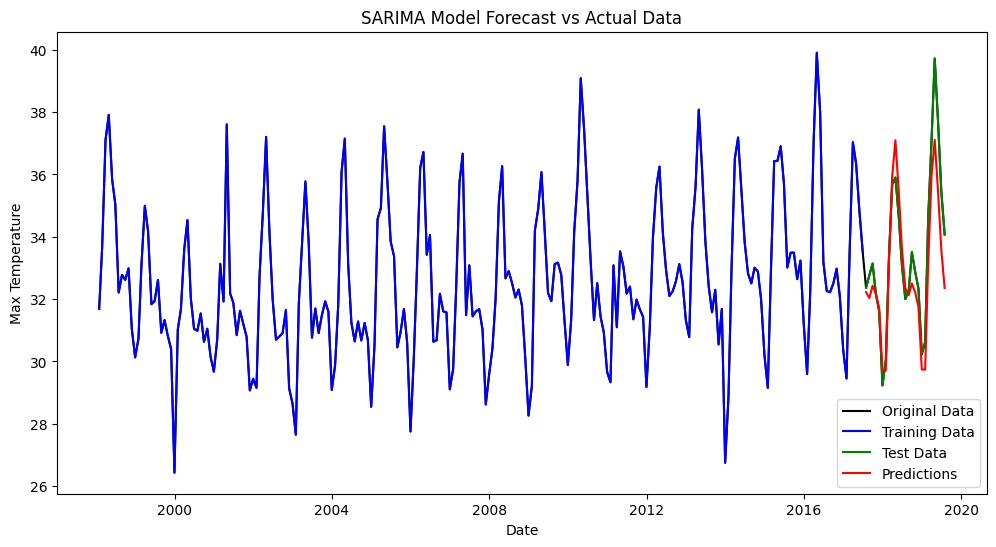

In [51]:
import matplotlib.pyplot as plt

pred = best_model.get_prediction(start=test.index.min(), end=test.index.max())
predictions = pred.predicted_mean

plt.figure(figsize=(12, 6))

plt.plot(monthly, label='Original Data', color='black')

plt.plot(train, label='Training Data', color='blue')

plt.plot(test, label='Test Data', color='green')

plt.plot(predictions, label='Predictions', color='red')

plt.legend()
plt.title('SARIMA Model Forecast vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Max Temperature')
plt.show()
